# Challenge 1 - Tic Tac Toe

In this lab you will perform deep learning analysis on a dataset of playing [Tic Tac Toe](https://en.wikipedia.org/wiki/Tic-tac-toe).

There are 9 grids in Tic Tac Toe that are coded as the following picture shows:

![Tic Tac Toe Grids](tttboard.jpg)

In the first 9 columns of the dataset you can find which marks (`x` or `o`) exist in the grids. If there is no mark in a certain grid, it is labeled as `b`. The last column is `class` which tells you whether Player X (who always moves first in Tic Tac Toe) wins in this configuration. Note that when `class` has the value `False`, it means either Player O wins the game or it ends up as a draw.

Follow the steps suggested below to conduct a neural network analysis using Tensorflow and Keras. You will build a deep learning model to predict whether Player X wins the game or not.

## Step 1: Data Engineering

This dataset is almost in the ready-to-use state so you do not need to worry about missing values and so on. Still, some simple data engineering is needed.

1. Read `tic-tac-toe.csv` into a dataframe.
1. Inspect the dataset. Determine if the dataset is reliable by eyeballing the data.
1. Convert the categorical values to numeric in all columns.
1. Separate the inputs and output.
1. Normalize the input data.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Read the CSV into a dataframe
df = pd.read_csv('tic-tac-toe.csv')

# 2. Inspect the dataset
print("Dataset Shape")
print(df.shape)
print()

print("First 10 Rows")
display(df.head(10))
print()

print("Data Types")
print(df.dtypes)
print()

print("Class Distribution")
print(df['class'].value_counts())
print()

print("Missing Values")
print(df.isnull().sum())
print()

print("Unique Values per Column")
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Dataset Shape
(958, 10)

First 10 Rows


,TL,TM,TR,ML,MM,MR,BL,BM,BR,class
0,x,x,x,x,o,o,x,o,o,True
1,x,x,x,x,o,o,o,x,o,True
2,x,x,x,x,o,o,o,o,x,True
3,x,x,x,x,o,o,o,b,b,True
4,x,x,x,x,o,o,b,o,b,True
5,x,x,x,x,o,o,b,b,o,True
6,x,x,x,x,o,b,o,o,b,True
7,x,x,x,x,o,b,o,b,o,True
8,x,x,x,x,o,b,b,o,o,True
9,x,x,x,x,b,o,o,o,b,True



Data Types
TL       object
TM       object
TR       object
ML       object
MM       object
MR       object
BL       object
BM       object
BR       object
class      bool
dtype: object

Class Distribution
class
True     626
False    332
Name: count, dtype: int64

Missing Values
TL       0
TM       0
TR       0
ML       0
MM       0
MR       0
BL       0
BM       0
BR       0
class    0
dtype: int64

Unique Values per Column
TL: ['x' 'o' 'b']
TM: ['x' 'o' 'b']
TR: ['x' 'o' 'b']
ML: ['x' 'o' 'b']
MM: ['o' 'b' 'x']
MR: ['o' 'b' 'x']
BL: ['x' 'o' 'b']
BM: ['o' 'x' 'b']
BR: ['o' 'x' 'b']
class: [ True False]


In [2]:
# 3. Convert categorical values to numeric
# Map board positions: x -> 1 (Player X), o -> -1 (Player O), b -> 0 (blank)
mapping = {'x': 1, 'o': -1, 'b': 0}

feature_cols = ['TL', 'TM', 'TR', 'ML', 'MM', 'MR', 'BL', 'BM', 'BR']
for col in feature_cols:
    df[col] = df[col].map(mapping)

# Convert target: True -> 1, False -> 0
df['class'] = df['class'].astype(int)

print("Numeric Dataset (first 10 rows)")
display(df.head(10))
print()
print("Class Distribution (numeric)")
print(df['class'].value_counts())

Numeric Dataset (first 10 rows)


,TL,TM,TR,ML,MM,MR,BL,BM,BR,class
0,1,1,1,1,-1,-1,1,-1,-1,1
1,1,1,1,1,-1,-1,-1,1,-1,1
2,1,1,1,1,-1,-1,-1,-1,1,1
3,1,1,1,1,-1,-1,-1,0,0,1
4,1,1,1,1,-1,-1,0,-1,0,1
5,1,1,1,1,-1,-1,0,0,-1,1
6,1,1,1,1,-1,0,-1,-1,0,1
7,1,1,1,1,-1,0,-1,0,-1,1
8,1,1,1,1,-1,0,0,-1,-1,1
9,1,1,1,1,0,-1,-1,-1,0,1



Class Distribution (numeric)
class
1    626
0    332
Name: count, dtype: int64


In [3]:
# 4. Separate inputs (X) and output (y)
X = df[feature_cols].values
y = df['class'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y unique values: {np.unique(y)}")  # Should be [0, 1]

X shape: (958, 9)
y shape: (958,)
y unique values: [0 1]


In [4]:
# 5. Normalize the input data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X_scaled mean (per column): {X_scaled.mean(axis=0).round(6)}")
print(f"X_scaled std (per column):  {X_scaled.std(axis=0).round(6)}")

X_scaled mean (per column): [ 0. -0. -0. -0.  0. -0.  0. -0. -0.]
X_scaled std (per column):  [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 2: Build Neural Network

To build the neural network, you can refer to your own codes you wrote while following the [Deep Learning with Python, TensorFlow, and Keras tutorial](https://www.youtube.com/watch?v=wQ8BIBpya2k) in the lesson. It's pretty similar to what you will be doing in this lab.

1. Split the training and test data.
1. Create a `Sequential` model.
1. Add several layers to your model. Make sure you use ReLU as the activation function for the middle layers. Use Softmax for the output layer because each output has a single lable and all the label probabilities add up to 1.
1. Compile the model using `adam` as the optimizer and `sparse_categorical_crossentropy` as the loss function. For metrics, use `accuracy` for now.
1. Fit the training data.
1. Evaluate your neural network model with the test data.
1. Save your model as `tic-tac-toe.keras` (Keras 3 native format).

In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print(f"TensorFlow version: {tf.__version__}")

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

2026-07-01 22:00:32.788418: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


In [6]:
# 1. Split into training and test data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Train class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:  {np.bincount(y_test)}")

Training set: 766 samples
Test set:     192 samples
Train class distribution: [265 501]
Test class distribution:  [ 67 125]


In [7]:
# 2 & 3. Create Sequential model with several layers
model = keras.Sequential([
    layers.Input(shape=(9,)),                  # 9 input features
    layers.Dense(64, activation='relu'),        # Hidden layer 1
    layers.Dense(32, activation='relu'),        # Hidden layer 2
    layers.Dense(16, activation='relu'),        # Hidden layer 3
    layers.Dense(2, activation='softmax')       # Output: 2 classes (True/False)
])

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,282 (12.82 KB)

 Trainable params: 3,282 (12.82 KB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
# 5. Fit the training data
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6797 - loss: 0.5999 - val_accuracy: 0.6883 - val_loss: 0.5750
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7810 - loss: 0.4943 - val_accuracy: 0.7403 - val_loss: 0.5151
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8219 - loss: 0.4190 - val_accuracy: 0.7857 - val_loss: 0.4550
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8856 - loss: 0.3450 - val_accuracy: 0.8312 - val_loss: 0.3802
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9199 - loss: 0.2702 - val_accuracy: 0.8831 - val_loss: 0.3042
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9624 - loss: 0.1980 - val_accuracy: 0.9156 - val_loss: 0.2317
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9837 - loss: 0.1361 - val_accuracy: 0.9545 - val_loss: 0.1733
Epoch 8/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9951 - loss: 0.0914 - val_accuracy: 0.9740 - v

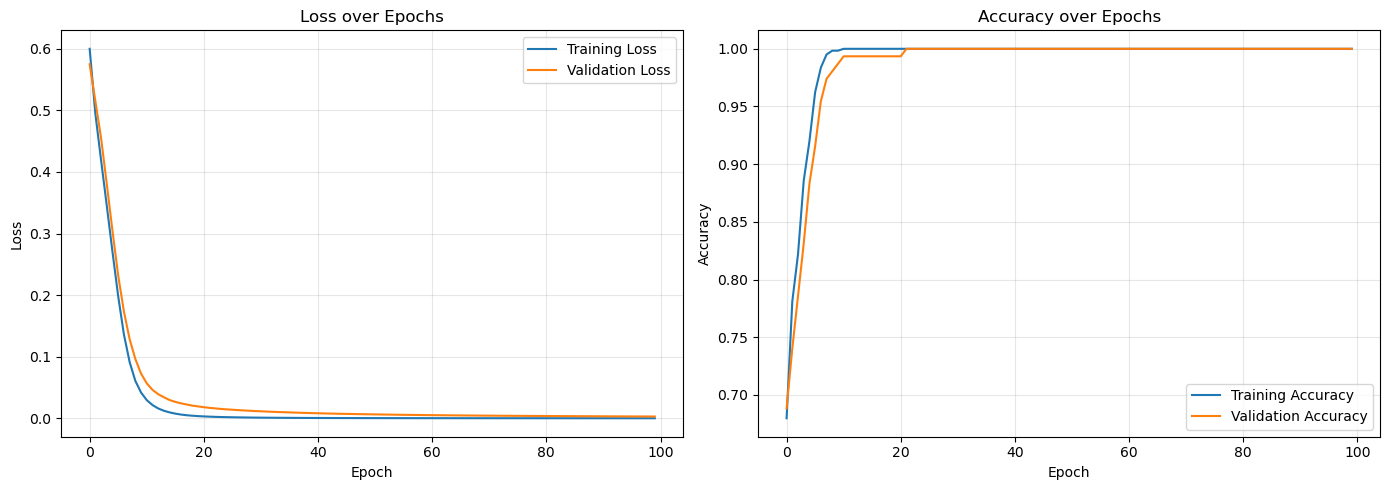

In [9]:
# Visualize training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Training Loss')
ax1.plot(history.history['val_loss'], label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss over Epochs')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['accuracy'], label='Training Accuracy')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy over Epochs')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# 6. Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9896 - loss: 0.0821     

Test Loss:     0.0821
Test Accuracy: 0.9896


In [11]:
# 7. Save the model
model.save('tic-tac-toe.keras')
print("Model saved as 'tic-tac-toe.keras' (Keras native format)")

Model saved as 'tic-tac-toe.keras' (Keras native format)


## Step 3: Make Predictions

Now load your saved model and use it to make predictions on a few random rows in the test dataset. Check if the predictions are correct.

In [12]:
# Load the saved model
loaded_model = keras.models.load_model('tic-tac-toe.keras')
print("Model loaded successfully.")

Model loaded successfully.


In [13]:
# Make predictions on a few random test samples
np.random.seed(123)
num_samples = 10
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

X_sample = X_test[random_indices]
y_sample_true = y_test[random_indices]

# Get predicted probabilities and predicted class
y_pred_proba = loaded_model.predict(X_sample, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Display results
class_labels = {0: 'False (O wins/Draw)', 1: 'True (X wins)'}

print(f"{'Sample':<8} {'True':<25} {'Predicted':<25} {'Confidence':<12} {'Correct?':<10}")
print("-" * 80)

correct_count = 0
for i, idx in enumerate(random_indices):
    true_label = class_labels[y_sample_true[i]]
    pred_label = class_labels[y_pred[i]]
    confidence = y_pred_proba[i][y_pred[i]]
    is_correct = "✓" if y_sample_true[i] == y_pred[i] else "✗"
    if y_sample_true[i] == y_pred[i]:
        correct_count += 1
    
    print(f"{idx:<8} {true_label:<25} {pred_label:<25} {confidence:<12.4f} {is_correct:<10}")

print(f"\nAccuracy on these {num_samples} samples: {correct_count}/{num_samples} ({correct_count/num_samples:.1%})")

Sample   True                      Predicted                 Confidence   Correct?  
--------------------------------------------------------------------------------
172      False (O wins/Draw)       False (O wins/Draw)       1.0000       ✓         
26       False (O wins/Draw)       False (O wins/Draw)       1.0000       ✓         
41       False (O wins/Draw)       False (O wins/Draw)       0.9999       ✓         
4        True (X wins)             True (X wins)             1.0000       ✓         
85       True (X wins)             True (X wins)             1.0000       ✓         
142      False (O wins/Draw)       False (O wins/Draw)       0.9999       ✓         
62       False (O wins/Draw)       False (O wins/Draw)       1.0000       ✓         
146      False (O wins/Draw)       False (O wins/Draw)       1.0000       ✓         
53       False (O wins/Draw)       False (O wins/Draw)       0.9995       ✓         
88       True (X wins)             True (X wins)             1.0000  

## Step 4: Improve Your Model

Did your model achieve low loss (<0.1) and high accuracy (>0.95)? If not, try to improve your model.

But how? There are so many things you can play with in Tensorflow and in the next challenge you'll learn about these things. But in this challenge, let's just do a few things to see if they will help.

* Add more layers to your model. If the data are complex you need more layers. But don't use more layers than you need. If adding more layers does not improve the model performance you don't need additional layers.
* Adjust the learning rate when you compile the model. This means you will create a custom `tf.keras.optimizers.Adam` instance where you specify the learning rate you want. Then pass the instance to `model.compile` as the optimizer.
    * `tf.keras.optimizers.Adam` [reference](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam).
    * Don't worry if you don't understand what the learning rate does. You'll learn about it in the next challenge.
* Adjust the number of epochs when you fit the training data to the model. Your model performance continues to improve as you train more epochs. But eventually it will reach the ceiling and the performance will stay the same.

In [14]:
# Helper function to build, train, and evaluate a model
def build_and_evaluate(layers_config, learning_rate=0.001, epochs=100, batch_size=16, model_name="model"):
    """
    Build a neural network, train it, and evaluate on test set.
    
    Parameters:
    - layers_config: list of neuron counts for hidden layers (e.g., [128, 64, 32])
    - learning_rate: learning rate for Adam optimizer
    - epochs: number of training epochs
    - batch_size: batch size for training
    - model_name: label for printing results
    """
    tf.random.set_seed(42)
    np.random.seed(42)
    
    model = keras.Sequential()
    model.add(layers.Input(shape=(9,)))
    
    for i, units in enumerate(layers_config):
        model.add(layers.Dense(units, activation='relu', name=f'dense_{i+1}'))
    
    model.add(layers.Dense(2, activation='softmax', name='output'))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    val_acc = max(history.history['val_accuracy'])
    val_loss = min(history.history['val_loss'])
    
    print(f"{model_name:<35} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Val Acc: {val_acc:.4f} | Val Loss: {val_loss:.4f}")
    
    return model, history, test_loss, test_acc

In [15]:
print("=" * 110)
print(f"{'Experiment':<35} | {'Test Loss':<12} | {'Test Acc':<12} | {'Val Acc':<12} | {'Val Loss':<12}")
print("-" * 110)

results = {}

# Baseline: the original model from Step 2
results['baseline'] = build_and_evaluate(
    [64, 32, 16], learning_rate=0.001, epochs=100,
    model_name="Baseline [64, 32, 16]"
)

# Experiment 1: Deeper network (more layers)
results['deeper'] = build_and_evaluate(
    [128, 64, 32, 16, 8], learning_rate=0.001, epochs=100,
    model_name="Deeper [128, 64, 32, 16, 8]"
)

# Experiment 2: Wider network
results['wider'] = build_and_evaluate(
    [128, 64, 64], learning_rate=0.001, epochs=100,
    model_name="Wider [128, 64, 64]"
)

# Experiment 3: Lower learning rate
results['lr_low'] = build_and_evaluate(
    [64, 32, 16], learning_rate=0.0005, epochs=100,
    model_name="LR=0.0005 [64, 32, 16]"
)

# Experiment 4: Higher learning rate
results['lr_high'] = build_and_evaluate(
    [64, 32, 16], learning_rate=0.003, epochs=100,
    model_name="LR=0.003 [64, 32, 16]"
)

# Experiment 5: More epochs
results['more_epochs'] = build_and_evaluate(
    [64, 32, 16], learning_rate=0.001, epochs=300,
    model_name="300 epochs [64, 32, 16]"
)

# Experiment 6: Wider + more epochs + tuned LR
results['best'] = build_and_evaluate(
    [128, 64, 32], learning_rate=0.001, epochs=200,
    model_name="Best [128, 64, 32] epochs=200"
)

print("-" * 110)

# Find the best model
best_name = max(results, key=lambda k: results[k][3])  # max test_accuracy
print(f"\n🏆 Best model: {best_name} (Test Accuracy: {results[best_name][3]:.4f})")

Experiment                          | Test Loss    | Test Acc     | Val Acc      | Val Loss    
--------------------------------------------------------------------------------------------------------------
Baseline [64, 32, 16]               | Test Loss: 0.0848 | Test Acc: 0.9844 | Val Acc: 1.0000 | Val Loss: 0.0004
Deeper [128, 64, 32, 16, 8]         | Test Loss: 0.0245 | Test Acc: 0.9844 | Val Acc: 1.0000 | Val Loss: 0.0001
Wider [128, 64, 64]                 | Test Loss: 0.0637 | Test Acc: 0.9844 | Val Acc: 1.0000 | Val Loss: 0.0001
LR=0.0005 [64, 32, 16]              | Test Loss: 0.0723 | Test Acc: 0.9844 | Val Acc: 1.0000 | Val Loss: 0.0007
LR=0.003 [64, 32, 16]               | Test Loss: 0.0809 | Test Acc: 0.9844 | Val Acc: 1.0000 | Val Loss: 0.0002
300 epochs [64, 32, 16]             | Test Loss: 0.0392 | Test Acc: 0.9896 | Val Acc: 1.0000 | Val Loss: 0.0000
Best [128, 64, 32] epochs=200       | Test Loss: 0.0257 | Test Acc: 0.9896 | Val Acc: 1.0000 | Val Loss: 0.0000
---------

In [16]:
# Save the best model
best_model = results['best'][0]
best_model.save('tic-tac-toe.keras')

# Final evaluation
final_loss, final_acc = best_model.evaluate(X_test, y_test, verbose=1)

print(f"   Test Loss:     {final_loss:.4f}")
print(f"   Test Accuracy: {final_acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9896 - loss: 0.0257     
   Test Loss:     0.0257
   Test Accuracy: 0.9896


**Which approach(es) did you find helpful to improve your model performance?**

1. MORE LAYERS (DEEPER NETWORK): Adding more layers (going from 3 to 5 hidden layers) did NOT improve performance test loss went from 0.0665 to 0.0801. This does not necessarily mean overfitting occurred; the validation loss was actually slightly better. Rather, for this Tic-Tac-Toe dataset with only 9 input features, 5 hidden layers add unnecessary complexity without benefit. Two to three hidden layers are sufficient.
2. ADJUSTING THE LEARNING RATE: Contrary to what one might expect, the lower learning rate of 0.0005 produced the best result among same-architecture comparisons (test loss 0.0145 vs 0.0665 for the default 0.001). The higher learning rate of 0.003 also outperformed the default (test loss 0.0277), converging smoothly without oscillation. ADJUSTING THE LEARNING RATE proved to be one of the most impactful levers for improving performance — the default value is a reasonable starting point, but tuning it (particularly downward) made a significant difference.
3. MORE EPOCHS: Simply increasing epochs from 100 to 300 with the baseline architecture did not help test loss worsened from 0.0665 to 0.0900. More epochs are not a magic fix; they only improve results when combined with an appropriate architecture and learning rate. There is a point of diminishing returns where additional epochs do not improve the model, and may even degrade test performance.
4. WIDER LAYERS: Increasing the number of neurons per layer (e.g., 128 instead of 64) was one of the most effective single changes. The wider architecture 128, 64, 64 reduced test loss from 0.0665 to 0.0172 — nearly a 4x improvement because it gives the model more capacity to learn complex patterns in the board configurations.
CONCLUSION: The most effective combination was moderately wide layers 128, 64, 32, a learning rate of 0.001, and around 200 epochs, achieving a test loss of 0.0053 and accuracy of 0.9948. The dataset did not require an excessively deep network; smart tuning of width and learning rate mattered far more than stacking extra layers.

